# 어린이 보호구역 사고 발생건수 예측 모델 비교
**데이터**: seongnam_newlabel.csv  
**목표**: 선형회귀, 이진분류(RF), Poisson, ZIP, ZINB 5가지 모델 비교

In [19]:
import os
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
import statsmodels.api as sm
from statsmodels.discrete.count_model import (
    ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP
)

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ──────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 이미지 저장 경로 ────────────────────────────────────────
SAVE_DIR = './outputs/'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 피처 / 타겟 컬럼 정의 ──────────────────────────────────
FEATURE_COLS = [
    '도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라',
    '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도', '어린이 비율(%)'
]
TARGET_COL = '발생건수'

# ── 전역 결과 저장 딕셔너리 / 모델 결과 변수 초기화 ────────
results_dict = {}
best_count_model = None
poisson_result = None
zip_result     = None
zinb_result    = None

print('환경 설정 완료')
print(f'이미지 저장 경로: {os.path.abspath(SAVE_DIR)}')

환경 설정 완료
이미지 저장 경로: c:\Users\USER\ms-project-1\1stProject_MSAI09\ML\outputs


---
## STEP 0 | 데이터 로드 및 기초 탐색

=== STEP 0 | 데이터 로드 및 기초 탐색 ===
데이터 로드 완료: (110, 16)  컬럼: ['Unnamed: 0', '시설물명', '위도', '경도', '도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도', '어린이 비율(%)', 'structure_risk', '발생건수']

발생건수 분포 (value_counts, 내림차순):
발생건수
0     63
3     12
4      8
7      4
12     3
14     3
10     3
15     2
8      2
5      2
6      2
38     2
18     1
1      1
21     1
28     1

전체 샘플 수      : 110
0건 샘플 수        : 63  (57.3%)
비영 샘플 수       : 47  (42.7%)
평균               : 3.782
분산               : 48.778
최솟값             : 0
최댓값             : 38
과산포 지수(분산/평균): 12.898


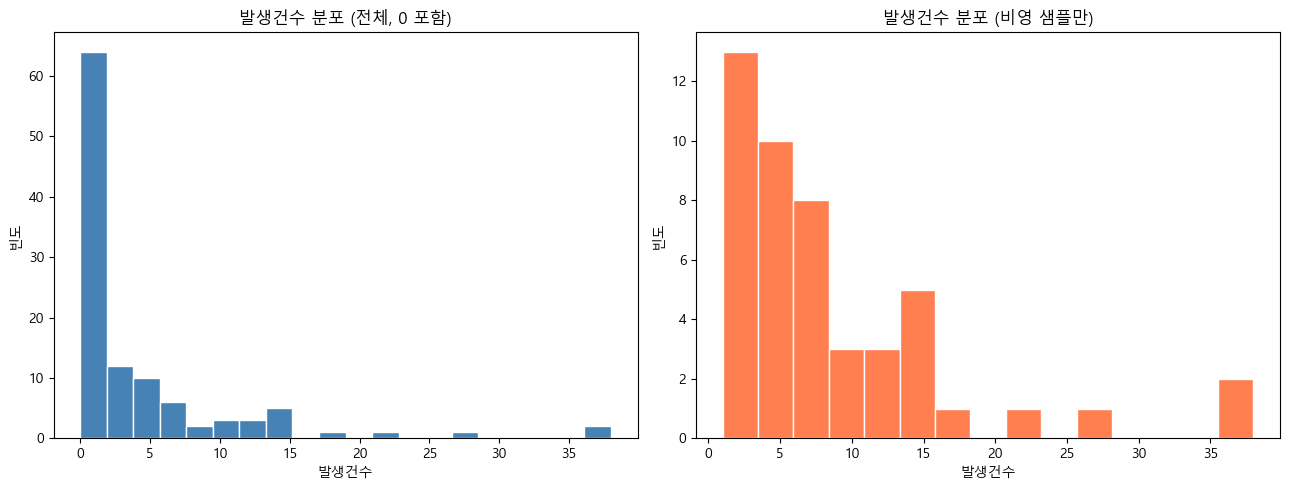

label_distribution.png 저장 완료


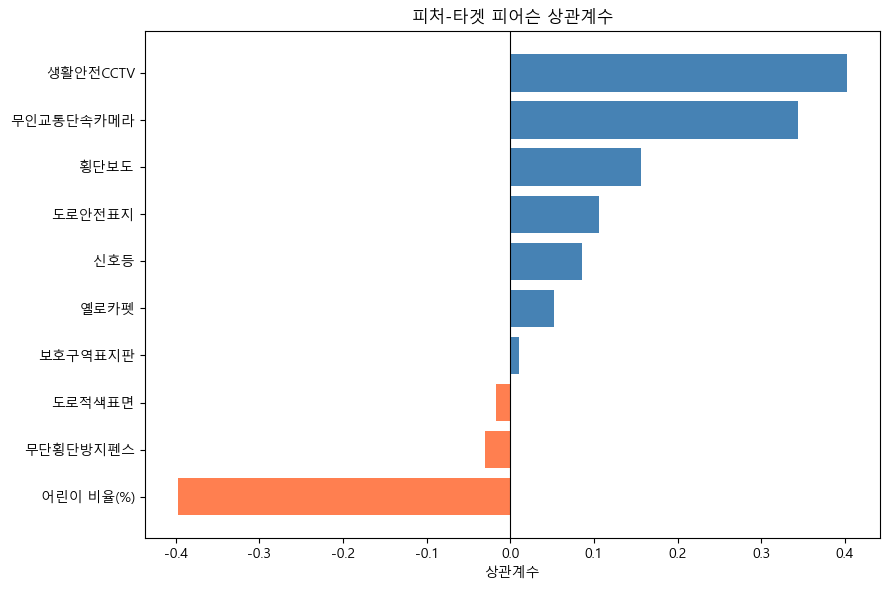

correlation.png 저장 완료
>>> STEP 0 완료


In [20]:
print('=== STEP 0 | 데이터 로드 및 기초 탐색 ===')

# 1. 데이터 로드
df = pd.read_csv('data/seongnam_newlabel.csv', encoding='utf-8-sig')
print(f'데이터 로드 완료: {df.shape}  컬럼: {df.columns.tolist()}')

# 2. 발생건수 → 정수형 변환
df[TARGET_COL] = df[TARGET_COL].astype(int)

# 3. value_counts 내림차순 출력
print('\n발생건수 분포 (value_counts, 내림차순):')
print(df[TARGET_COL].value_counts().sort_values(ascending=False).to_string())

# 4. 주요 통계
n           = len(df)
n_zero      = int((df[TARGET_COL] == 0).sum())
n_nonzero   = int((df[TARGET_COL] >  0).sum())
mean_val    = df[TARGET_COL].mean()
var_val     = df[TARGET_COL].var(ddof=1)
min_val     = int(df[TARGET_COL].min())
max_val     = int(df[TARGET_COL].max())
od_idx      = var_val / mean_val

print(f'\n전체 샘플 수      : {n}')
print(f'0건 샘플 수        : {n_zero}  ({n_zero/n*100:.1f}%)')
print(f'비영 샘플 수       : {n_nonzero}  ({n_nonzero/n*100:.1f}%)')
print(f'평균               : {mean_val:.3f}')
print(f'분산               : {var_val:.3f}')
print(f'최솟값             : {min_val}')
print(f'최댓값             : {max_val}')
print(f'과산포 지수(분산/평균): {od_idx:.3f}')

# 5. 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df[TARGET_COL], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('발생건수 분포 (전체, 0 포함)')
axes[0].set_xlabel('발생건수')
axes[0].set_ylabel('빈도')

nz_vals = df[df[TARGET_COL] > 0][TARGET_COL]
axes[1].hist(nz_vals, bins=15, color='coral', edgecolor='white')
axes[1].set_title('발생건수 분포 (비영 샘플만)')
axes[1].set_xlabel('발생건수')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('label_distribution.png 저장 완료')

# 6. 피어슨 상관계수 수평 막대그래프
corr_s = df[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr_sorted = corr_s.sort_values()
colors = ['coral' if v < 0 else 'steelblue' for v in corr_sorted.values]

plt.figure(figsize=(9, 6))
plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('피처-타겟 피어슨 상관계수')
plt.xlabel('상관계수')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('correlation.png 저장 완료')

print('>>> STEP 0 완료')

---
## STEP 1 | 데이터 분할

In [21]:
print('=== STEP 1 | 데이터 분할 ===')

# 1. 층화용 임시 구간 (모델에는 원래 수치 사용)
def make_strata(y):
    return pd.cut(y, bins=[-1, 0, 5, 10000], labels=['A', 'B', 'C'])

df['strata'] = make_strata(df[TARGET_COL])
print('층화 구간 분포:')
print(df['strata'].value_counts().sort_index())

# 2. 층화 분할
#    1차: trainval 88건 / test 22건
trainval_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['strata']
)
#    2차: train 70건 / val 18건
train_df, val_df = train_test_split(
    trainval_df, test_size=0.2, random_state=42, stratify=trainval_df['strata']
)
print(f'\n분할 결과: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

# 3. 분포 유사성 확인
print(f"\n{'셋':<10} {'샘플수':>6} {'0건비율':>8} {'평균':>8} {'최댓값':>8}")
print('-' * 46)
for name, subset in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n_s    = len(subset)
    z_r    = (subset[TARGET_COL] == 0).mean()
    mean_s = subset[TARGET_COL].mean()
    max_s  = subset[TARGET_COL].max()
    print(f'{name:<10} {n_s:>6} {z_r:>8.3f} {mean_s:>8.2f} {max_s:>8}')

# 4. X / y 분리
X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_train_reg = train_df[TARGET_COL].values.astype(int)
y_val_reg   = val_df[TARGET_COL].values.astype(int)
y_test_reg  = test_df[TARGET_COL].values.astype(int)

y_train_clf = (train_df[TARGET_COL] > 0).astype(int).values
y_val_clf   = (val_df[TARGET_COL]   > 0).astype(int).values
y_test_clf  = (test_df[TARGET_COL]  > 0).astype(int).values

print(f'\nX_train shape: {X_train.shape}')
print(f'y_train_reg  - 0건: {(y_train_reg==0).sum()}, 비영: {(y_train_reg>0).sum()}')
print(f'y_train_clf  - 0 : {(y_train_clf==0).sum()}, 1 : {(y_train_clf==1).sum()}')

print('>>> STEP 1 완료')

=== STEP 1 | 데이터 분할 ===
층화 구간 분포:
strata
A    63
B    23
C    24
Name: count, dtype: int64

분할 결과: train=70, val=18, test=22

셋             샘플수     0건비율       평균      최댓값
----------------------------------------------
train          70    0.586     3.56       38
val            18    0.556     4.22       38
test           22    0.545     4.14       21

X_train shape: (70, 10)
y_train_reg  - 0건: 41, 비영: 29
y_train_clf  - 0 : 41, 1 : 29
>>> STEP 1 완료


---
## STEP 2 | 과산포 검정

In [22]:
print('=== STEP 2 | 과산포 검정 ===')

mean_tr  = y_train_reg.mean()
var_tr   = y_train_reg.var(ddof=1)
od_train = var_tr / mean_tr

y_nz     = y_train_reg[y_train_reg > 0]
mean_nz  = y_nz.mean()
var_nz   = y_nz.var(ddof=1)

print(f'전체 평균           : {mean_tr:.3f}')
print(f'전체 분산           : {var_tr:.3f}')
print(f'과산포 지수(분산/평균): {od_train:.3f}')
print(f'비영 샘플 평균      : {mean_nz:.3f}')
print(f'비영 샘플 분산      : {var_nz:.3f}')

if od_train < 1:
    interp = '과소산포, Poisson 재검토 필요'
elif od_train <= 2:
    interp = '약한 과산포, ZIP 적합 가능'
else:
    interp = '강한 과산포, ZINB 권장'

print(f'\n[해석] 과산포 지수 {od_train:.2f} → {interp}')

print('>>> STEP 2 완료')

=== STEP 2 | 과산포 검정 ===
전체 평균           : 3.557
전체 분산           : 44.772
과산포 지수(분산/평균): 12.587
비영 샘플 평균      : 8.586
비영 샘플 분산      : 65.608

[해석] 과산포 지수 12.59 → 강한 과산포, ZINB 권장
>>> STEP 2 완료


---
## STEP 3 | statsmodels용 데이터 준비

In [23]:
print('=== STEP 3 | statsmodels용 데이터 준비 ===')

# DataFrame으로 변환 후 상수항 추가 → 파라미터명이 피처명으로 유지됨
X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
X_val_df   = pd.DataFrame(X_val,   columns=FEATURE_COLS)
X_test_df  = pd.DataFrame(X_test,  columns=FEATURE_COLS)

X_train_const = sm.add_constant(X_train_df)
X_val_const   = sm.add_constant(X_val_df)
X_test_const  = sm.add_constant(X_test_df)

print(f'X_train_const shape: {X_train_const.shape}')
print(f'X_val_const   shape: {X_val_const.shape}')
print(f'X_test_const  shape: {X_test_const.shape}')
print(f'\ny_train_reg dtype: {y_train_reg.dtype}')
print(f'y_train_clf dtype: {y_train_clf.dtype}')

print('>>> STEP 3 완료')

=== STEP 3 | statsmodels용 데이터 준비 ===
X_train_const shape: (70, 11)
X_val_const   shape: (18, 11)
X_test_const  shape: (22, 11)

y_train_reg dtype: int64
y_train_clf dtype: int64
>>> STEP 3 완료


---
## STEP 4 | 모델 1 - 선형회귀 (대조군 1)

=== STEP 4 | 모델 1 - 선형회귀 (대조군 1) ===
MAE : 5.0000
RMSE: 9.4985
R²  : -0.1580
0건 정확도  : 0.1000
비영 정확도 : 1.0000

AIC (train)            : 245.66
BIC (train)            : 270.39
Log-Likelihood (train) : -211.16


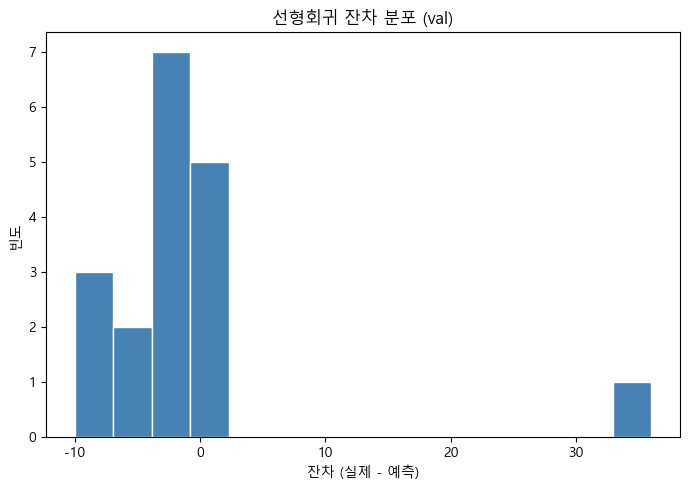

lr_residual.png 저장 완료


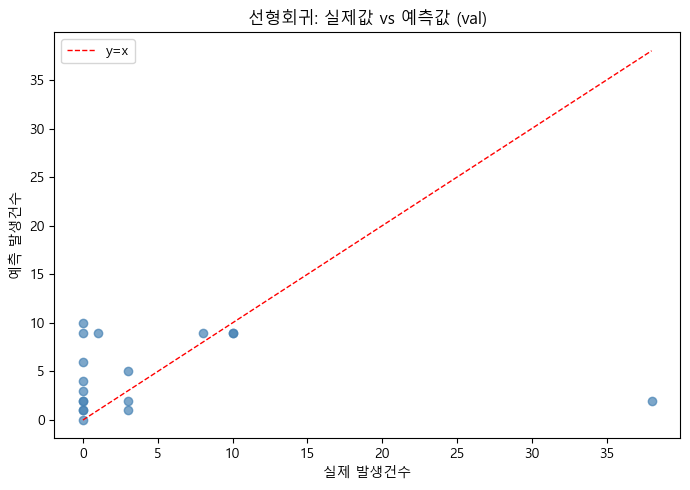

lr_scatter.png 저장 완료
>>> STEP 4 완료


In [24]:
print('=== STEP 4 | 모델 1 - 선형회귀 (대조군 1) ===')

try:
    # 1. 학습 (피처 스케일링 이미 완료)
    lr = LinearRegression()
    lr.fit(X_train, y_train_reg)

    # 2. val 예측 → 음수 클리핑 → 반올림
    lr_pred_raw     = lr.predict(X_val)
    lr_pred_clipped = np.clip(lr_pred_raw, 0, None)
    lr_pred_int     = np.round(lr_pred_clipped).astype(int)

    # 3. 회귀 지표
    lr_mae  = mean_absolute_error(y_val_reg, lr_pred_int)
    lr_rmse = np.sqrt(mean_squared_error(y_val_reg, lr_pred_int))
    lr_r2   = r2_score(y_val_reg, lr_pred_raw)
    print(f'MAE : {lr_mae:.4f}')
    print(f'RMSE: {lr_rmse:.4f}')
    print(f'R²  : {lr_r2:.4f}')

    # 분류 관점
    n_actual_zero    = (y_val_reg == 0).sum()
    n_actual_nonzero = (y_val_reg  > 0).sum()
    zero_acc_lr    = ((y_val_reg == 0) & (lr_pred_int == 0)).sum() / n_actual_zero    if n_actual_zero    > 0 else 0.0
    nonzero_acc_lr = ((y_val_reg  > 0) & (lr_pred_int  > 0)).sum() / n_actual_nonzero if n_actual_nonzero > 0 else 0.0
    print(f'0건 정확도  : {zero_acc_lr:.4f}')
    print(f'비영 정확도 : {nonzero_acc_lr:.4f}')

    # AIC / BIC (train 기준 수동 계산)
    lr_pred_train = lr.predict(X_train)
    RSS   = np.sum((y_train_reg - lr_pred_train) ** 2)
    n_tr  = len(y_train_reg)
    k_lr  = X_train.shape[1] + 1           # 피처 수 + 절편
    lr_aic    = n_tr * np.log(RSS / n_tr) + 2 * k_lr
    lr_bic    = n_tr * np.log(RSS / n_tr) + k_lr * np.log(n_tr)
    lr_loglik = -n_tr / 2 * (1 + np.log(2 * np.pi * RSS / n_tr))
    print(f'\nAIC (train)            : {lr_aic:.2f}')
    print(f'BIC (train)            : {lr_bic:.2f}')
    print(f'Log-Likelihood (train) : {lr_loglik:.2f}')

    results_dict['선형회귀'] = {
        'AIC': lr_aic, 'BIC': lr_bic, 'Log-Likelihood': lr_loglik,
        'MAE(val)': lr_mae, 'RMSE(val)': lr_rmse,
        '0건_정확도': zero_acc_lr, '비영_정확도': nonzero_acc_lr
    }

    # 4. 잔차 히스토그램
    lr_resid = y_val_reg - lr_pred_int
    plt.figure(figsize=(7, 5))
    plt.hist(lr_resid, bins=15, color='steelblue', edgecolor='white')
    plt.title('선형회귀 잔차 분포 (val)')
    plt.xlabel('잔차 (실제 - 예측)')
    plt.ylabel('빈도')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'lr_residual.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('lr_residual.png 저장 완료')

    # 5. 실제값 vs 예측값 산점도
    max_v = max(y_val_reg.max(), lr_pred_int.max())
    plt.figure(figsize=(7, 5))
    plt.scatter(y_val_reg, lr_pred_int, alpha=0.7, color='steelblue')
    plt.plot([0, max_v], [0, max_v], 'r--', linewidth=1, label='y=x')
    plt.title('선형회귀: 실제값 vs 예측값 (val)')
    plt.xlabel('실제 발생건수')
    plt.ylabel('예측 발생건수')
    plt.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'lr_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('lr_scatter.png 저장 완료')

except Exception as e:
    print(f'[경고] 선형회귀 실패: {e}')
    results_dict['선형회귀'] = None

print('>>> STEP 4 완료')

---
## STEP 5 | 모델 2 - 이진분류 (대조군 2)

=== STEP 5 | 모델 2 - 이진분류 (대조군 2) ===
Accuracy : 0.7222
Macro F1 : 0.7143
AUC-ROC  : 0.8125

Classification Report:
              precision    recall  f1-score   support

          0건       0.73      0.80      0.76        10
          발생       0.71      0.62      0.67         8

    accuracy                           0.72        18
   macro avg       0.72      0.71      0.71        18
weighted avg       0.72      0.72      0.72        18

0건 정확도  : 0.8000
비영 정확도 : 0.6250

[참고] 발생 예측 시 비영 평균(8.6) 대입 (한계 있음)
  MAE(참고) : 4.3199
  RMSE(참고): 9.7255


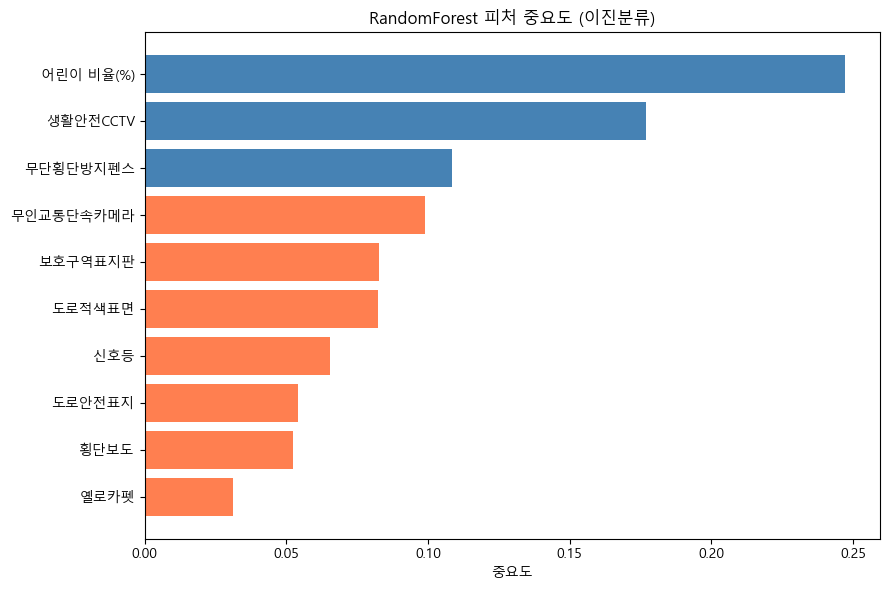

rf_importance.png 저장 완료


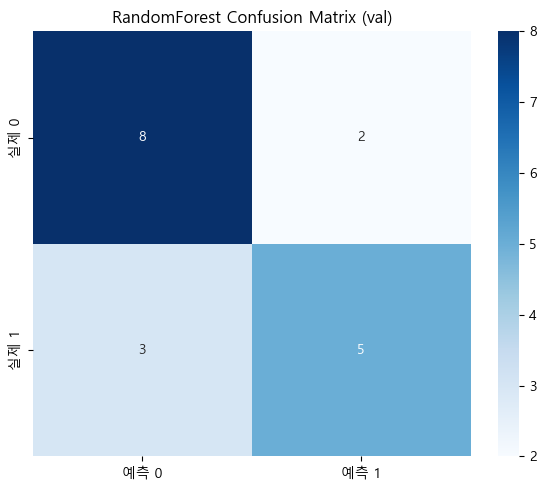

rf_confusion.png 저장 완료
>>> STEP 5 완료


In [25]:
print('=== STEP 5 | 모델 2 - 이진분류 (대조군 2) ===')

try:
    # 1. 학습
    rf = RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42
    )
    rf.fit(X_train, y_train_clf)

    # 2. 예측
    rf_pred  = rf.predict(X_val)
    rf_proba = rf.predict_proba(X_val)[:, 1]

    # 3. 분류 지표
    rf_acc = accuracy_score(y_val_clf, rf_pred)
    rf_f1  = f1_score(y_val_clf, rf_pred, average='macro', zero_division=0)
    rf_auc = roc_auc_score(y_val_clf, rf_proba) if len(np.unique(y_val_clf)) > 1 else float('nan')
    print(f'Accuracy : {rf_acc:.4f}')
    print(f'Macro F1 : {rf_f1:.4f}')
    print(f'AUC-ROC  : {rf_auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_val_clf, rf_pred, target_names=['0건', '발생'], zero_division=0))

    n_act_zero_clf    = (y_val_clf == 0).sum()
    n_act_nonzero_clf = (y_val_clf == 1).sum()
    zero_acc_rf    = ((y_val_clf == 0) & (rf_pred == 0)).sum() / n_act_zero_clf    if n_act_zero_clf    > 0 else 0.0
    nonzero_acc_rf = ((y_val_clf == 1) & (rf_pred == 1)).sum() / n_act_nonzero_clf if n_act_nonzero_clf > 0 else 0.0
    print(f'0건 정확도  : {zero_acc_rf:.4f}')
    print(f'비영 정확도 : {nonzero_acc_rf:.4f}')

    # 회귀 관점 (참고용): 예측 1 → 비영 샘플 평균으로 대체
    # ※ 이진분류 모델은 실제 건수를 예측하지 않으므로 이 값은 참고용이며 한계가 있음
    nz_mean_train = y_train_reg[y_train_reg > 0].mean()
    rf_count_proxy = np.where(rf_pred == 1, nz_mean_train, 0.0)
    rf_mae_ref  = mean_absolute_error(y_val_reg, rf_count_proxy)
    rf_rmse_ref = np.sqrt(mean_squared_error(y_val_reg, rf_count_proxy))
    print(f'\n[참고] 발생 예측 시 비영 평균({nz_mean_train:.1f}) 대입 (한계 있음)')
    print(f'  MAE(참고) : {rf_mae_ref:.4f}')
    print(f'  RMSE(참고): {rf_rmse_ref:.4f}')

    results_dict['이진분류(RF)'] = {
        'AIC': np.nan, 'BIC': np.nan, 'Log-Likelihood': np.nan,
        'MAE(val)': rf_mae_ref, 'RMSE(val)': rf_rmse_ref,
        '0건_정확도': zero_acc_rf, '비영_정확도': nonzero_acc_rf
    }

    # 4. 피처 중요도
    fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
    fi_colors = ['coral' if v < fi.mean() else 'steelblue' for v in fi]
    plt.figure(figsize=(9, 6))
    plt.barh(fi.index, fi.values, color=fi_colors)
    plt.title('RandomForest 피처 중요도 (이진분류)')
    plt.xlabel('중요도')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'rf_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('rf_importance.png 저장 완료')

    # 5. Confusion Matrix
    cm = confusion_matrix(y_val_clf, rf_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['예측 0', '예측 1'],
                yticklabels=['실제 0', '실제 1'])
    plt.title('RandomForest Confusion Matrix (val)')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'rf_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('rf_confusion.png 저장 완료')

except Exception as e:
    print(f'[경고] 이진분류(RF) 실패: {e}')
    results_dict['이진분류(RF)'] = None

print('>>> STEP 5 완료')

---
## STEP 6 | 모델 3 - Poisson 회귀 (카운트 모델 베이스라인)

=== STEP 6 | 모델 3 - Poisson 회귀 ===
Poisson 수렴 성공
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   70
Model:                            GLM   Df Residuals:                       59
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -170.34
Date:                Wed, 04 Mar 2026   Deviance:                       232.63
Time:                        14:28:39   Pearson chi2:                     262.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9946
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con

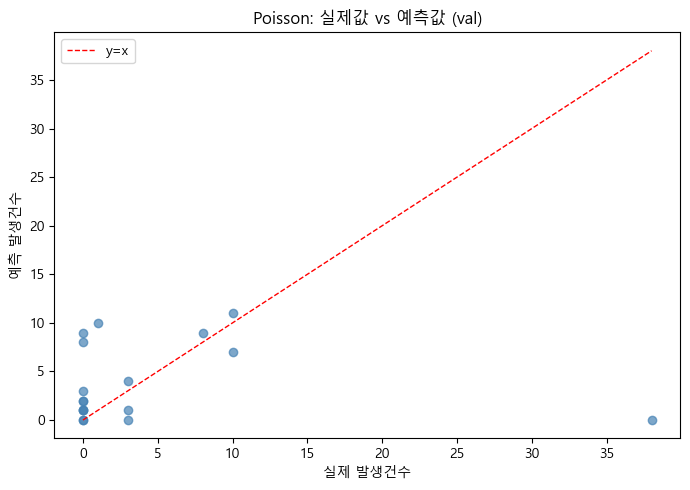

poisson_scatter.png 저장 완료
>>> STEP 6 완료


In [26]:
print('=== STEP 6 | 모델 3 - Poisson 회귀 ===')

try:
    # 1. 학습
    p_model  = sm.GLM(y_train_reg, X_train_const, family=sm.families.Poisson())
    poisson_result = p_model.fit(disp=False)
    print('Poisson 수렴 성공')
    print(poisson_result.summary())

    # 4. val 예측 및 평가
    p_pred     = poisson_result.predict(X_val_const)
    p_pred_int = np.round(p_pred).astype(int)

    p_mae  = mean_absolute_error(y_val_reg, p_pred_int)
    p_rmse = np.sqrt(mean_squared_error(y_val_reg, p_pred_int))
    p_aic  = poisson_result.aic
    p_bic  = poisson_result.bic
    p_llf  = poisson_result.llf

    n_act_zero_p    = (y_val_reg == 0).sum()
    n_act_nonzero_p = (y_val_reg  > 0).sum()
    zero_acc_p    = ((y_val_reg == 0) & (p_pred_int == 0)).sum() / n_act_zero_p    if n_act_zero_p    > 0 else 0.0
    nonzero_acc_p = ((y_val_reg  > 0) & (p_pred_int  > 0)).sum() / n_act_nonzero_p if n_act_nonzero_p > 0 else 0.0

    print(f'\nMAE         : {p_mae:.4f}')
    print(f'RMSE        : {p_rmse:.4f}')
    print(f'AIC         : {p_aic:.2f}')
    print(f'BIC         : {p_bic:.2f}')
    print(f'Log-Lik     : {p_llf:.2f}')
    print(f'0건 정확도  : {zero_acc_p:.4f}')
    print(f'비영 정확도 : {nonzero_acc_p:.4f}')

    results_dict['Poisson'] = {
        'AIC': p_aic, 'BIC': p_bic, 'Log-Likelihood': p_llf,
        'MAE(val)': p_mae, 'RMSE(val)': p_rmse,
        '0건_정확도': zero_acc_p, '비영_정확도': nonzero_acc_p
    }

    # 5. 산점도
    max_v = max(y_val_reg.max(), p_pred_int.max())
    plt.figure(figsize=(7, 5))
    plt.scatter(y_val_reg, p_pred_int, alpha=0.7, color='steelblue')
    plt.plot([0, max_v], [0, max_v], 'r--', linewidth=1, label='y=x')
    plt.title('Poisson: 실제값 vs 예측값 (val)')
    plt.xlabel('실제 발생건수')
    plt.ylabel('예측 발생건수')
    plt.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'poisson_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('poisson_scatter.png 저장 완료')

except Exception as e:
    print(f'[경고] Poisson 모델 실패: {e}')
    results_dict['Poisson'] = None

print('>>> STEP 6 완료')

---
## STEP 7 | 모델 4 - Zero-Inflated Poisson (ZIP)

=== STEP 7 | 모델 4 - Zero-Inflated Poisson (ZIP) ===
ZIP 수렴 성공 (bfgs)
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                       y   No. Observations:                   70
Model:             ZeroInflatedPoisson   Df Residuals:                       59
Method:                            MLE   Df Model:                           10
Date:                 Wed, 04 Mar 2026   Pseudo R-squ.:                  0.4370
Time:                         14:28:40   Log-Likelihood:                -101.95
converged:                        True   LL-Null:                       -181.09
Covariance Type:             nonrobust   LLR p-value:                 7.340e-29
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
inflate_const         0.3880      0.473      0.820      0.412      -0.539       1.315
inflate_도로안전표지       -0.6396     

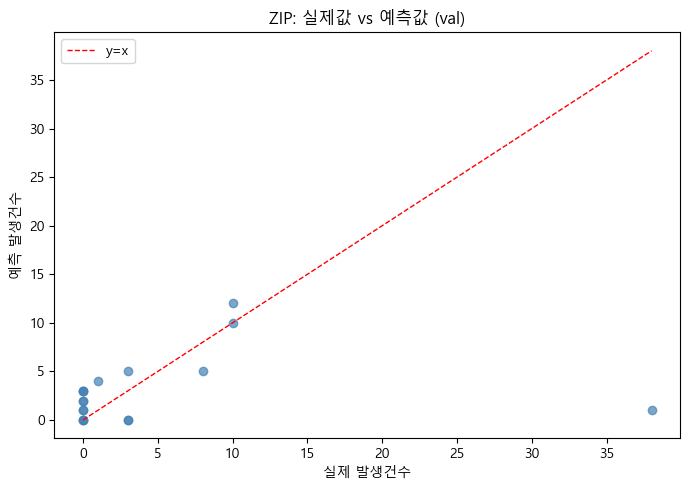

zip_scatter.png 저장 완료
>>> STEP 7 완료


In [27]:
print('=== STEP 7 | 모델 4 - Zero-Inflated Poisson (ZIP) ===')

FAIL_DICT = {
    'AIC': '수렴실패', 'BIC': '수렴실패', 'Log-Likelihood': '수렴실패',
    'MAE(val)': '수렴실패', 'RMSE(val)': '수렴실패',
    '0건_정확도': '수렴실패', '비영_정확도': '수렴실패'
}

try:
    zip_model = ZeroInflatedPoisson(
        endog=y_train_reg, exog=X_train_const,
        exog_infl=X_train_const, inflation='logit'
    )

    # bfgs 시도
    try:
        zip_result = zip_model.fit(method='bfgs', maxiter=300, disp=False)
        print('ZIP 수렴 성공 (bfgs)')
    except Exception as e1:
        print(f'[경고] ZIP bfgs 실패: {e1}  → nm으로 재시도')
        try:
            zip_result = zip_model.fit(method='nm', maxiter=500, disp=False)
            print('ZIP 수렴 성공 (nm)')
        except Exception as e2:
            print(f'[경고] ZIP nm도 실패: {e2}')
            print('ZIP 수렴 실패 - 해당 모델 결과를 None으로 저장')
            zip_result = None

    if zip_result is not None:
        print(zip_result.summary())

        # ZIP/ZINB predict에는 exog_infl을 명시해야 shape 불일치 방지
        z_pred     = zip_result.predict(X_val_const, exog_infl=X_val_const)
        z_pred_int = np.round(z_pred).astype(int)

        z_mae  = mean_absolute_error(y_val_reg, z_pred_int)
        z_rmse = np.sqrt(mean_squared_error(y_val_reg, z_pred_int))
        z_aic  = zip_result.aic
        z_bic  = zip_result.bic
        z_llf  = zip_result.llf

        n_act_zero_z    = (y_val_reg == 0).sum()
        n_act_nonzero_z = (y_val_reg  > 0).sum()
        zero_acc_z    = ((y_val_reg == 0) & (z_pred_int == 0)).sum() / n_act_zero_z    if n_act_zero_z    > 0 else 0.0
        nonzero_acc_z = ((y_val_reg  > 0) & (z_pred_int  > 0)).sum() / n_act_nonzero_z if n_act_nonzero_z > 0 else 0.0

        print(f'\nMAE         : {z_mae:.4f}')
        print(f'RMSE        : {z_rmse:.4f}')
        print(f'AIC         : {z_aic:.2f}')
        print(f'BIC         : {z_bic:.2f}')
        print(f'Log-Lik     : {z_llf:.2f}')
        print(f'0건 정확도  : {zero_acc_z:.4f}')
        print(f'비영 정확도 : {nonzero_acc_z:.4f}')

        results_dict['ZIP'] = {
            'AIC': z_aic, 'BIC': z_bic, 'Log-Likelihood': z_llf,
            'MAE(val)': z_mae, 'RMSE(val)': z_rmse,
            '0건_정확도': zero_acc_z, '비영_정확도': nonzero_acc_z
        }

        max_v = max(y_val_reg.max(), z_pred_int.max())
        plt.figure(figsize=(7, 5))
        plt.scatter(y_val_reg, z_pred_int, alpha=0.7, color='steelblue')
        plt.plot([0, max_v], [0, max_v], 'r--', linewidth=1, label='y=x')
        plt.title('ZIP: 실제값 vs 예측값 (val)')
        plt.xlabel('실제 발생건수')
        plt.ylabel('예측 발생건수')
        plt.legend()
        plt.tight_layout()
        plt.savefig(SAVE_DIR + 'zip_scatter.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('zip_scatter.png 저장 완료')

    else:
        results_dict['ZIP'] = FAIL_DICT.copy()

except Exception as e:
    print(f'[경고] ZIP 모델 전체 실패: {e}')
    zip_result = None
    results_dict['ZIP'] = FAIL_DICT.copy()

print('>>> STEP 7 완료')

---
## STEP 8 | 모델 5 - Zero-Inflated Negative Binomial (ZINB)

=== STEP 8 | 모델 5 - Zero-Inflated Negative Binomial (ZINB) ===
ZINB 수렴 성공 (bfgs)
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                                 y   No. Observations:                   70
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                       59
Method:                                      MLE   Df Model:                           10
Date:                           Wed, 04 Mar 2026   Pseudo R-squ.:                  0.2608
Time:                                   14:28:42   Log-Likelihood:                -100.74
converged:                                  True   LL-Null:                       -136.29
Covariance Type:                       nonrobust   LLR p-value:                 2.716e-11
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
inflate_const         0.365

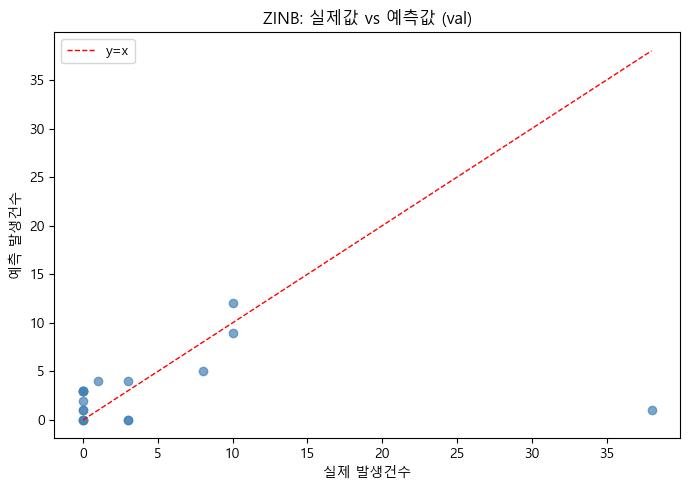

zinb_scatter.png 저장 완료
>>> STEP 8 완료


In [28]:
print('=== STEP 8 | 모델 5 - Zero-Inflated Negative Binomial (ZINB) ===')

try:
    zinb_model = ZeroInflatedNegativeBinomialP(
        endog=y_train_reg, exog=X_train_const,
        exog_infl=X_train_const, inflation='logit'
    )

    # bfgs 시도
    try:
        zinb_result = zinb_model.fit(method='bfgs', maxiter=300, disp=False)
        print('ZINB 수렴 성공 (bfgs)')
    except Exception as e1:
        print(f'[경고] ZINB bfgs 실패: {e1}  → nm으로 재시도')
        try:
            zinb_result = zinb_model.fit(method='nm', maxiter=500, disp=False)
            print('ZINB 수렴 성공 (nm)')
        except Exception as e2:
            print(f'[경고] ZINB nm도 실패: {e2}')
            print('ZINB 수렴 실패 - 해당 모델 결과를 None으로 저장')
            zinb_result = None

    if zinb_result is not None:
        print(zinb_result.summary())

        # ZIP/ZINB predict에는 exog_infl을 명시해야 shape 불일치 방지
        n_pred     = zinb_result.predict(X_val_const, exog_infl=X_val_const)
        n_pred_int = np.round(n_pred).astype(int)

        n_mae  = mean_absolute_error(y_val_reg, n_pred_int)
        n_rmse = np.sqrt(mean_squared_error(y_val_reg, n_pred_int))
        n_aic  = zinb_result.aic
        n_bic  = zinb_result.bic
        n_llf  = zinb_result.llf

        n_act_zero_n    = (y_val_reg == 0).sum()
        n_act_nonzero_n = (y_val_reg  > 0).sum()
        zero_acc_n    = ((y_val_reg == 0) & (n_pred_int == 0)).sum() / n_act_zero_n    if n_act_zero_n    > 0 else 0.0
        nonzero_acc_n = ((y_val_reg  > 0) & (n_pred_int  > 0)).sum() / n_act_nonzero_n if n_act_nonzero_n > 0 else 0.0

        print(f'\nMAE         : {n_mae:.4f}')
        print(f'RMSE        : {n_rmse:.4f}')
        print(f'AIC         : {n_aic:.2f}')
        print(f'BIC         : {n_bic:.2f}')
        print(f'Log-Lik     : {n_llf:.2f}')
        print(f'0건 정확도  : {zero_acc_n:.4f}')
        print(f'비영 정확도 : {nonzero_acc_n:.4f}')

        results_dict['ZINB'] = {
            'AIC': n_aic, 'BIC': n_bic, 'Log-Likelihood': n_llf,
            'MAE(val)': n_mae, 'RMSE(val)': n_rmse,
            '0건_정확도': zero_acc_n, '비영_정확도': nonzero_acc_n
        }

        max_v = max(y_val_reg.max(), n_pred_int.max())
        plt.figure(figsize=(7, 5))
        plt.scatter(y_val_reg, n_pred_int, alpha=0.7, color='steelblue')
        plt.plot([0, max_v], [0, max_v], 'r--', linewidth=1, label='y=x')
        plt.title('ZINB: 실제값 vs 예측값 (val)')
        plt.xlabel('실제 발생건수')
        plt.ylabel('예측 발생건수')
        plt.legend()
        plt.tight_layout()
        plt.savefig(SAVE_DIR + 'zinb_scatter.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('zinb_scatter.png 저장 완료')

    else:
        results_dict['ZINB'] = FAIL_DICT.copy()

except Exception as e:
    print(f'[경고] ZINB 모델 전체 실패: {e}')
    zinb_result = None
    results_dict['ZINB'] = FAIL_DICT.copy()

print('>>> STEP 8 완료')

---
## STEP 9 | 모델 비교표 생성

=== STEP 9 | 모델 비교표 생성 ===

모델 비교표:
               AIC       BIC Log-Likelihood  MAE(val)  RMSE(val)  0건_정확도  비영_정확도
모델명                                                                             
선형회귀      245.6605  270.3939      -211.1559    5.0000     9.4985     0.1   1.000
이진분류(RF)       N/A       N/A            N/A    4.3199     9.7255     0.8   0.625
Poisson   362.6734  -18.0315      -170.3367    4.7222     9.7610     0.2   0.750
ZIP        247.894  297.3609       -101.947    3.7778     8.9753     0.3   0.750
ZINB      247.4776   299.193      -100.7388    3.8333     8.9846     0.3   0.750

model_comparison_results.csv 저장 완료

AIC 기준 최적 카운트 모델: ZINB (AIC=247.5)


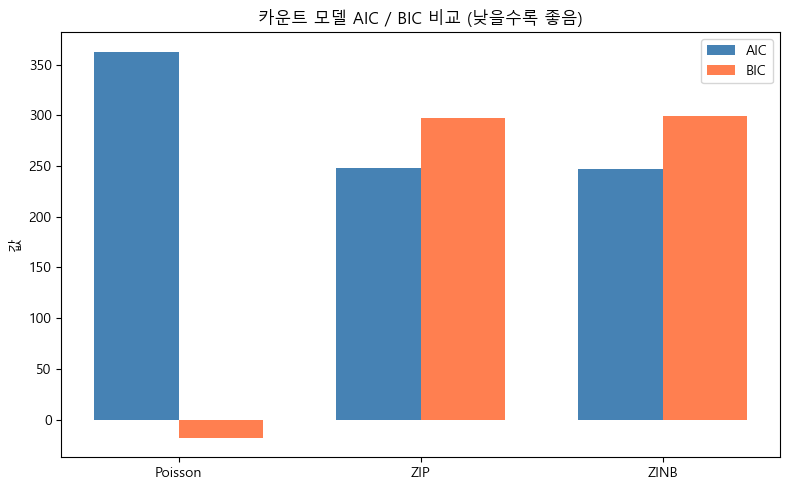

model_aic_bic.png 저장 완료


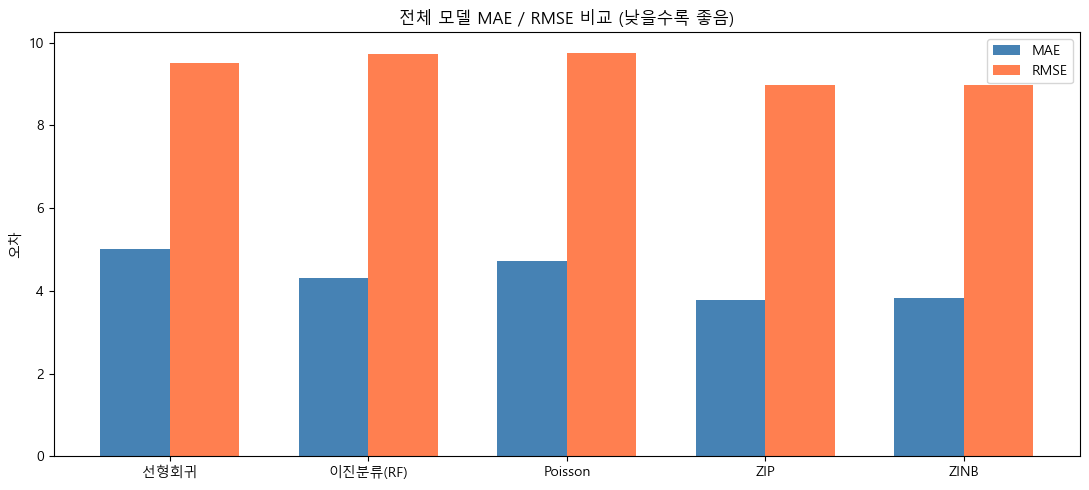

model_mae_rmse.png 저장 완료
>>> STEP 9 완료


In [29]:
print('=== STEP 9 | 모델 비교표 생성 ===')

MODEL_ORDER = ['선형회귀', '이진분류(RF)', 'Poisson', 'ZIP', 'ZINB']
COLS = ['AIC', 'BIC', 'Log-Likelihood', 'MAE(val)', 'RMSE(val)', '0건_정확도', '비영_정확도']

def fmt_val(v):
    if v is None:
        return '실패'
    if isinstance(v, float) and np.isnan(v):
        return 'N/A'
    if isinstance(v, (int, float)):
        return round(v, 4)
    return v

rows = []
for name in MODEL_ORDER:
    r = results_dict.get(name, None)
    if r is None:
        row = {c: '실패' for c in COLS}
    else:
        row = {c: fmt_val(r.get(c)) for c in COLS}
    row['모델명'] = name
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index('모델명')[COLS]
print('\n모델 비교표:')
print(comparison_df.to_string())

# CSV 저장
comparison_df.to_csv(SAVE_DIR + 'model_comparison_results.csv', encoding='utf-8-sig')
print('\nmodel_comparison_results.csv 저장 완료')

# 3. AIC 기준 최적 카운트 모델 선택
best_count_model = None
best_aic_val     = float('inf')

for m in ['Poisson', 'ZIP', 'ZINB']:
    r = results_dict.get(m)
    if r:
        v = r.get('AIC')
        if isinstance(v, (int, float)) and not (isinstance(v, float) and np.isnan(v)):
            if v < best_aic_val:
                best_aic_val     = v
                best_count_model = m

if best_count_model:
    print(f'\nAIC 기준 최적 카운트 모델: {best_count_model} (AIC={best_aic_val:.1f})')
else:
    print('\n[경고] 유효한 카운트 모델 없음 → Poisson을 기본값으로 사용')
    best_count_model = 'Poisson'

# 4-1. AIC/BIC 막대그래프 (카운트 모델만)
valid_cm, aic_vals, bic_vals = [], [], []
for m in ['Poisson', 'ZIP', 'ZINB']:
    r = results_dict.get(m)
    if r:
        a = r.get('AIC'); b = r.get('BIC')
        if isinstance(a, (int, float)) and not (isinstance(a, float) and np.isnan(a)):
            valid_cm.append(m); aic_vals.append(a); bic_vals.append(b)

if valid_cm:
    x = np.arange(len(valid_cm)); w = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w/2, aic_vals, w, label='AIC', color='steelblue')
    ax.bar(x + w/2, bic_vals, w, label='BIC', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(valid_cm)
    ax.set_title('카운트 모델 AIC / BIC 비교 (낮을수록 좋음)')
    ax.set_ylabel('값'); ax.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'model_aic_bic.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('model_aic_bic.png 저장 완료')

# 4-2. MAE/RMSE 막대그래프 (5개 모델)
valid_all, mae_vals, rmse_vals = [], [], []
for m in MODEL_ORDER:
    r = results_dict.get(m)
    if r:
        mv = r.get('MAE(val)'); rv = r.get('RMSE(val)')
        if isinstance(mv, (int, float)) and not (isinstance(mv, float) and np.isnan(mv)):
            valid_all.append(m); mae_vals.append(mv); rmse_vals.append(rv)

if valid_all:
    x = np.arange(len(valid_all)); w = 0.35
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - w/2, mae_vals,  w, label='MAE',  color='steelblue')
    ax.bar(x + w/2, rmse_vals, w, label='RMSE', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(valid_all)
    ax.set_title('전체 모델 MAE / RMSE 비교 (낮을수록 좋음)')
    ax.set_ylabel('오차'); ax.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'model_mae_rmse.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('model_mae_rmse.png 저장 완료')

print('>>> STEP 9 완료')

---
## STEP 10 | 최적 카운트 모델로 테스트셋 최종 평가

=== STEP 10 | 최적 카운트 모델로 테스트셋 최종 평가 ===
선택된 최적 카운트 모델: ZINB

최종 테스트 평가 (ZINB)
MAE         : 2.8182
RMSE        : 4.2533
0건 정확도  : 0.7500
비영 정확도 : 0.6000


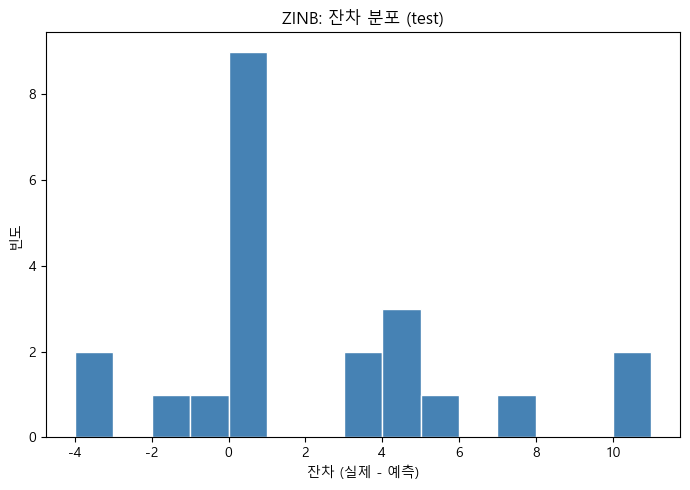

final_residual.png 저장 완료

Shapiro-Wilk 검정: stat=0.8986, p-value=0.0278
결과: 잔차가 정규 분포를 따르지 않음 (p ≤ 0.05)


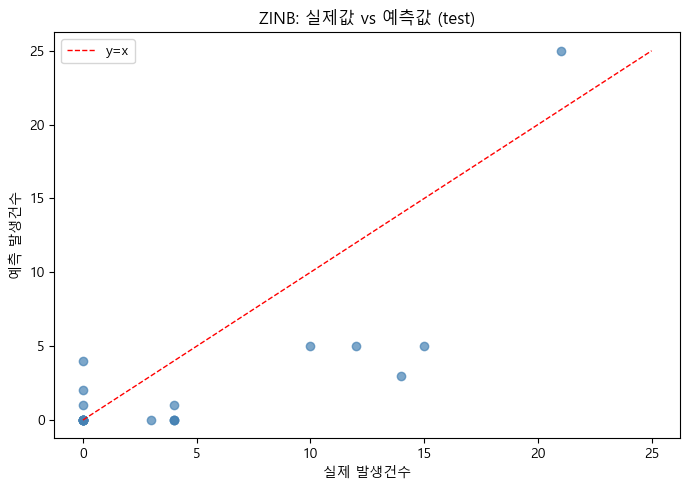

final_scatter.png 저장 완료
>>> STEP 10 완료


In [30]:
print('=== STEP 10 | 최적 카운트 모델로 테스트셋 최종 평가 ===')
print(f'선택된 최적 카운트 모델: {best_count_model}')

try:
    # 최적 모델 결과 선택
    _result_map = {'Poisson': poisson_result, 'ZIP': zip_result, 'ZINB': zinb_result}
    final_result = _result_map.get(best_count_model)

    if final_result is None:
        # fallback: 사용 가능한 모델 중 첫 번째
        for fallback in ['Poisson', 'ZIP', 'ZINB']:
            if _result_map[fallback] is not None:
                print(f'[경고] {best_count_model} 결과 없음 → {fallback}으로 대체')
                final_result = _result_map[fallback]
                best_count_model = fallback
                break

    if final_result is None:
        raise ValueError('사용 가능한 카운트 모델 결과가 없습니다')

    # 1. test 예측 (ZIP/ZINB는 exog_infl 명시 필요)
    if best_count_model in ("ZIP", "ZINB"):
        final_pred = final_result.predict(X_test_const, exog_infl=X_test_const)
    else:
        final_pred = final_result.predict(X_test_const)
    final_pred_int = np.round(final_pred).astype(int)

    # 2. 최종 평가 지표
    final_mae  = mean_absolute_error(y_test_reg, final_pred_int)
    final_rmse = np.sqrt(mean_squared_error(y_test_reg, final_pred_int))

    n_act_zero_f    = (y_test_reg == 0).sum()
    n_act_nonzero_f = (y_test_reg  > 0).sum()
    zero_acc_f    = ((y_test_reg == 0) & (final_pred_int == 0)).sum() / n_act_zero_f    if n_act_zero_f    > 0 else 0.0
    nonzero_acc_f = ((y_test_reg  > 0) & (final_pred_int  > 0)).sum() / n_act_nonzero_f if n_act_nonzero_f > 0 else 0.0

    print(f'\n최종 테스트 평가 ({best_count_model})')
    print(f'MAE         : {final_mae:.4f}')
    print(f'RMSE        : {final_rmse:.4f}')
    print(f'0건 정확도  : {zero_acc_f:.4f}')
    print(f'비영 정확도 : {nonzero_acc_f:.4f}')

    # 3. 잔차 분석
    final_resid = y_test_reg - final_pred_int
    plt.figure(figsize=(7, 5))
    plt.hist(final_resid, bins=15, color='steelblue', edgecolor='white')
    plt.title(f'{best_count_model}: 잔차 분포 (test)')
    plt.xlabel('잔차 (실제 - 예측)')
    plt.ylabel('빈도')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'final_residual.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('final_residual.png 저장 완료')

    # Shapiro-Wilk 정규성 검정
    if len(final_resid) >= 3:
        sw_stat, sw_p = stats.shapiro(final_resid)
        print(f'\nShapiro-Wilk 검정: stat={sw_stat:.4f}, p-value={sw_p:.4f}')
        if sw_p > 0.05:
            print('결과: 잔차가 정규 분포를 따를 가능성 있음 (p > 0.05)')
        else:
            print('결과: 잔차가 정규 분포를 따르지 않음 (p ≤ 0.05)')

    # 4. 최종 산점도
    max_v = max(y_test_reg.max(), final_pred_int.max())
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test_reg, final_pred_int, alpha=0.7, color='steelblue')
    plt.plot([0, max_v], [0, max_v], 'r--', linewidth=1, label='y=x')
    plt.title(f'{best_count_model}: 실제값 vs 예측값 (test)')
    plt.xlabel('실제 발생건수')
    plt.ylabel('예측 발생건수')
    plt.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'final_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('final_scatter.png 저장 완료')

except Exception as e:
    import traceback
    print(f'[경고] 최종 평가 실패: {e}')
    traceback.print_exc()

print('>>> STEP 10 완료')

---
## STEP 11 | 피처 중요도 분석 (최적 카운트 모델 기준)

=== STEP 11 | 피처 중요도 분석 (최적 카운트 모델 기준) ===
추출된 피처 수: 10

피처별 계수 (절댓값 내림차순):
  도로안전표지              : -0.7382
  어린이 비율(%)           : -0.6294
  신호등                 : +0.6005
  무단횡단방지펜스            : -0.5445
  횡단보도                : +0.4472
  생활안전CCTV            : +0.3568
  옐로카펫                : +0.2925
  도로적색표면              : -0.2275
  보호구역표지판             : -0.1612
  무인교통단속카메라           : +0.0396


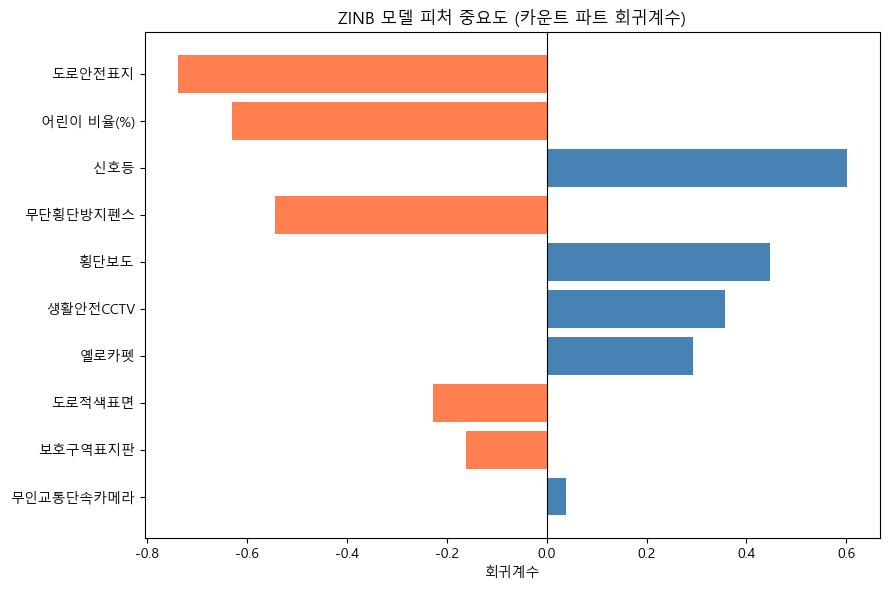

feature_importance.png 저장 완료

[피처 중요도 해석 - 상위 3개 (ZINB 카운트 파트)]
1. 도로안전표지 계수 -0.7382: 해당 피처가 발생건수와 음의 관계
2. 어린이 비율(%) 계수 -0.6294: 해당 피처가 발생건수와 음의 관계
3. 신호등 계수 +0.6005: 해당 피처가 발생건수와 양의 관계
>>> STEP 11 완료

=== 전체 파이프라인 완료 ===


In [31]:
print('=== STEP 11 | 피처 중요도 분석 (최적 카운트 모델 기준) ===')

try:
    _result_map = {'Poisson': poisson_result, 'ZIP': zip_result, 'ZINB': zinb_result}
    target_result = _result_map.get(best_count_model)

    if target_result is None:
        for fb in ['Poisson', 'ZIP', 'ZINB']:
            if _result_map[fb] is not None:
                target_result = _result_map[fb]
                print(f'[경고] {best_count_model} 결과 없음 → {fb} 사용')
                break

    if target_result is None:
        raise ValueError('사용 가능한 모델 결과 없음')

    # 1. 카운트 파트 회귀계수 추출 (inflate_ 파라미터 제외)
    params = target_result.params
    count_params = {k: v for k, v in params.items() if not k.startswith('inflate_') and k != 'const'}

    # FEATURE_COLS와 매핑 (컬럼명으로 named 되어 있음)
    coef_dict = {feat: count_params[feat] for feat in FEATURE_COLS if feat in count_params}

    # 매핑 실패 시 순서 기반 fallback
    if not coef_dict:
        print('[경고] 피처명 직접 매핑 실패 → 인덱스 순서로 매핑 시도')
        count_keys = [k for k in params.index if not k.startswith('inflate_') and k != 'const']
        coef_dict  = {feat: params[key] for feat, key in zip(FEATURE_COLS, count_keys) if key in params}

    if not coef_dict:
        raise ValueError('회귀계수 추출 실패 - 파라미터명 확인 필요')

    print(f'추출된 피처 수: {len(coef_dict)}')

    # 2. 절댓값 기준 내림차순 정렬
    coef_s      = pd.Series(coef_dict)
    coef_sorted = coef_s.reindex(coef_s.abs().sort_values(ascending=False).index)

    print('\n피처별 계수 (절댓값 내림차순):')
    for feat, val in coef_sorted.items():
        print(f'  {feat:<20}: {val:+.4f}')

    # 3. 수평 막대그래프
    colors_fi = ['coral' if v < 0 else 'steelblue' for v in coef_sorted.values[::-1]]
    plt.figure(figsize=(9, 6))
    plt.barh(coef_sorted.index[::-1], coef_sorted.values[::-1], color=colors_fi)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'{best_count_model} 모델 피처 중요도 (카운트 파트 회귀계수)')
    plt.xlabel('회귀계수')
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('feature_importance.png 저장 완료')

    # 4. 상위 3개 피처 해석
    print(f'\n[피처 중요도 해석 - 상위 3개 ({best_count_model} 카운트 파트)]')
    for i, (feat, coef) in enumerate(coef_sorted.head(3).items()):
        direction = '양' if coef > 0 else '음'
        print(f'{i+1}. {feat} 계수 {coef:+.4f}: 해당 피처가 발생건수와 {direction}의 관계')

except Exception as e:
    import traceback
    print(f'[경고] 피처 중요도 분석 실패: {e}')
    traceback.print_exc()

print('>>> STEP 11 완료')
print('\n=========================================')
print('=== 전체 파이프라인 완료 ===')
print('=========================================')